# 📊 Adım 1 — Veri Keşfi (EDA)
Bu notebook'ta veriyi tanıyoruz. Kod yazmadan önce **ne ile çalıştığımızı** anlamak şart.

---

## 1.1 Kütüphaneleri yükle
Her projede ilk hücre budur. Kullanacağımız araçları içe aktarıyoruz.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Grafik ayarları
plt.rcParams['figure.figsize'] = (10, 5)
sns.set_theme(style='whitegrid', palette='muted')

print('Kütüphaneler hazır ✓')

Kütüphaneler hazır ✓


## 1.2 Veriyi yükle
İki ayrı CSV var: biri normal gözler, biri papilödem tanısı alanlar.

> **NOT:** CSV dosyalarını bu notebook ile aynı klasöre koyduğunuzdan emin olun.

In [2]:
normal = pd.read_csv('normal_radiomics.csv')
papil  = pd.read_csv('papilodem_radiomics.csv')

print(f'Normal  → {normal.shape[0]} satır, {normal.shape[1]} sütun')
print(f'Papilödem → {papil.shape[0]} satır, {papil.shape[1]} sütun')

Normal  → 672 satır, 748 sütun
Papilödem → 294 satır, 748 sütun


## 1.3 İlk bakış — verinin yüzü
`head()` ilk 5 satırı gösterir. Sütun isimlerini ve değer tiplerini görürüz.

In [3]:
print('--- NORMAL (ilk 5 satır) ---')
display(normal.head())

print('\n--- PAPİLÖDEM (ilk 5 satır) ---')
display(papil.head())

--- NORMAL (ilk 5 satır) ---


,PatientIndex,SideStandard,Feature_0001,Feature_0002,Feature_0003,Feature_0004,Feature_0005,Feature_0006,Feature_0007,Feature_0008,...,Feature_0737,Feature_0738,Feature_0739,Feature_0740,Feature_0741,Feature_0742,Feature_0743,Feature_0744,Feature_0745,Feature_0746
0,1,Right,45448743,45448743,6.636275,13,26,95,163,57.307637,...,0.000046,0.303150,5.687919,2.473651,0.125228,9.296632,0.021759,1.306864,3.731575,298.961246
1,1,Right,33362854,33362854,6.321687,13,28,87,121,55.412374,...,0.000053,0.294247,5.846466,2.464606,0.344254,4.255490,0.068561,0.680029,9.035579,136.066301
2,1,Right,30680223,30680223,6.214364,20,28,83,114,54.242223,...,0.000056,0.301285,5.535349,2.472294,0.125899,9.254451,0.020573,1.257392,3.786161,298.993921
3,1,Right,38885845,38885845,6.443296,21,31,91,143,60.356027,...,0.000054,0.312013,5.530567,2.494216,0.125414,9.324893,0.021415,1.448996,3.622940,289.354936
4,1,Right,36867702,36867702,6.396227,21,31,91,129,59.868649,...,0.000056,0.311296,5.672677,2.472707,0.125754,9.332594,0.023086,1.307401,3.652652,293.592461



--- PAPİLÖDEM (ilk 5 satır) ---


,PatientIndex,SideStandard,Feature_0001,Feature_0002,Feature_0003,Feature_0004,Feature_0005,Feature_0006,Feature_0007,Feature_0008,...,Feature_0737,Feature_0738,Feature_0739,Feature_0740,Feature_0741,Feature_0742,Feature_0743,Feature_0744,Feature_0745,Feature_0746
0,1,Right,30259276,30259276,6.175943,19,29,77,165,50.778757,...,0.000053,0.436097,4.264210,2.693133,0.068295,16.559611,0.011433,2.362870,1.591344,406.879968
1,1,Right,28490306,28490306,6.164030,18,28,75,166,49.993481,...,0.000054,0.438471,4.489069,2.681561,0.068916,16.438471,0.012255,2.385825,1.646766,414.949181
2,1,Right,30701628,30701628,6.256489,16,27,80,167,50.490604,...,0.000053,0.470351,4.388110,2.723603,0.135172,9.631323,0.028018,1.511648,2.851264,225.815864
3,1,Right,27817329,27817329,6.143411,17,26,72,168,48.220212,...,0.000052,0.445624,4.502508,2.699718,0.069137,16.604529,0.013476,2.507635,1.650222,419.003235
4,1,Right,28759518,28759518,6.217389,14,26,75,170,48.372624,...,0.000051,0.477801,4.688352,2.759445,0.069034,16.628858,0.012178,2.602866,1.614236,413.924248


## 1.4 Hasta yapısını anla

Her satır bir hasta **değil** — her satır bir göz muayenesinin bir bileşeni (ROI).
Aynı hastanın birden fazla satırı var. Bu önemli: train/test bölerken **hasta bazında** bölmemiz gerekiyor, satır bazında değil.

In [4]:
print('=== HASTA BAZINDA ÖZET ===')
print(f"Normal   — unique hasta: {normal['PatientIndex'].nunique()}, toplam satır: {len(normal)}")
print(f"Papilödem — unique hasta: {papil['PatientIndex'].nunique()}, toplam satır: {len(papil)}")

print('\nHasta başına satır sayısı (normal):')
display(normal.groupby('PatientIndex').size().describe().to_frame('satır_sayısı').T)

print('\nSide dağılımı:')
print(normal['SideStandard'].value_counts())

=== HASTA BAZINDA ÖZET ===
Normal   — unique hasta: 48, toplam satır: 672
Papilödem — unique hasta: 21, toplam satır: 294

Hasta başına satır sayısı (normal):


,count,mean,std,min,25%,50%,75%,max
satır_sayısı,48.0,14.0,0.0,14.0,14.0,14.0,14.0,14.0



Side dağılımı:
SideStandard
Right    336
Left     336
Name: count, dtype: int64


## 1.5 Sınıf dengesizliği
Kaç normal, kaç papilödem hastası var? Model eğitiminde bu oranın etkisi büyük.

,Sınıf,Hasta,Satır,Hasta Oranı (%)
0,Normal (0),48,672,69.6
1,Papilödem (1),21,294,30.4


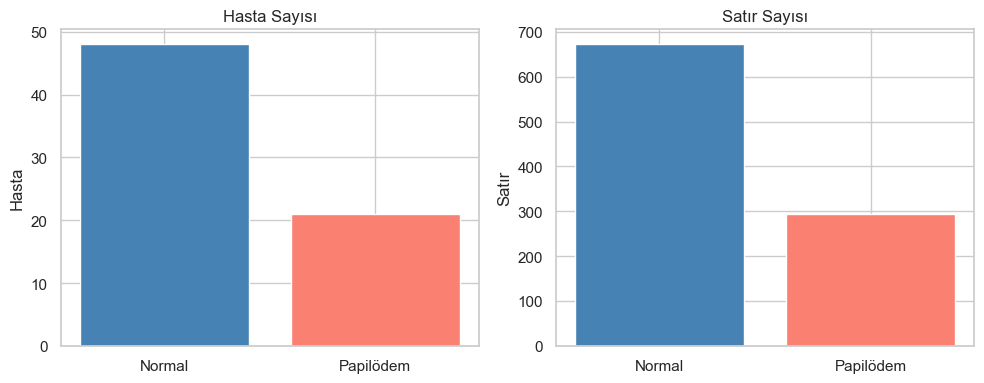

Grafik kaydedildi: fig_sinif_dagilimi.png


In [5]:
hasta_ozet = pd.DataFrame({
    'Sınıf':   ['Normal (0)', 'Papilödem (1)'],
    'Hasta':   [normal['PatientIndex'].nunique(), papil['PatientIndex'].nunique()],
    'Satır':   [len(normal), len(papil)]
})
hasta_ozet['Hasta Oranı (%)'] = (hasta_ozet['Hasta'] / hasta_ozet['Hasta'].sum() * 100).round(1)
display(hasta_ozet)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(['Normal', 'Papilödem'], hasta_ozet['Hasta'], color=['steelblue', 'salmon'])
axes[0].set_title('Hasta Sayısı')
axes[0].set_ylabel('Hasta')

axes[1].bar(['Normal', 'Papilödem'], hasta_ozet['Satır'], color=['steelblue', 'salmon'])
axes[1].set_title('Satır Sayısı')
axes[1].set_ylabel('Satır')

plt.tight_layout()
plt.savefig('fig_sinif_dagilimi.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafik kaydedildi: fig_sinif_dagilimi.png')

## 1.6 Eksik değer kontrolü
Makine öğrenmesi modelleri boş değerlerle çalışamaz. Kaç tane var?

In [6]:
eksik_normal = normal.isnull().sum().sum()
eksik_papil  = papil.isnull().sum().sum()

print(f'Normal veri — eksik değer: {eksik_normal}')
print(f'Papilödem   — eksik değer: {eksik_papil}')

if eksik_normal == 0 and eksik_papil == 0:
    print('\n✓ Eksik değer yok. Ön işleme bu adımı geçebiliriz ama pipeline içinde yine de uygulayacağız (iyi pratik).')

Normal veri — eksik değer: 0
Papilödem   — eksik değer: 0

✓ Eksik değer yok. Ön işleme bu adımı geçebiliriz ama pipeline içinde yine de uygulayacağız (iyi pratik).


## 1.7 Özellik istatistikleri
746 özelliğin genel dağılımına bakalım. Ölçekler çok farklı mı? Bu, neden RobustScaler kullandığımızı gösterir.

Toplam özellik sayısı: 746


/var/folders/yf/2lqvzyz17xx3kpqd50y09c_h0000gn/T/ipykernel_47245/1630420543.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  normal['label'] = 0
/var/folders/yf/2lqvzyz17xx3kpqd50y09c_h0000gn/T/ipykernel_47245/1630420543.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  papil['label']  = 1


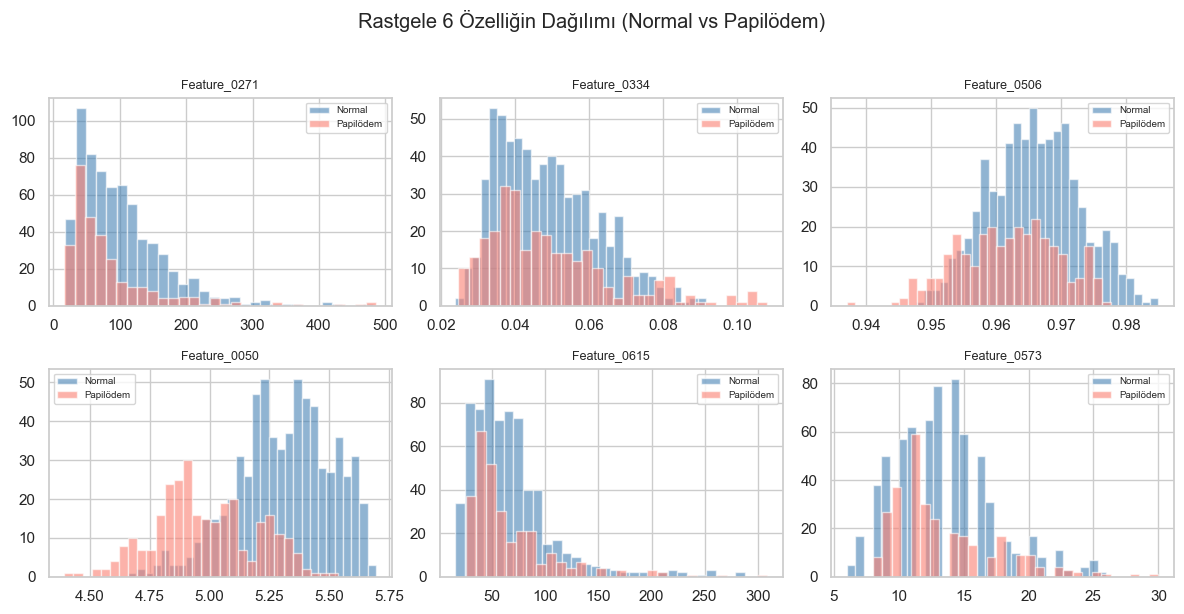

Grafik kaydedildi: fig_ozellik_dagilimi.png


In [7]:
feature_cols = [c for c in normal.columns if c.startswith('Feature_')]
print(f'Toplam özellik sayısı: {len(feature_cols)}')

# Tüm satırları birleştirerek özellik istatistiklerine bak
normal['label'] = 0
papil['label']  = 1
df = pd.concat([normal, papil], ignore_index=True)

# Rastgele 6 özelliğin dağılımı
sample_feats = np.random.choice(feature_cols, 6, replace=False)

fig, axes = plt.subplots(2, 3, figsize=(12, 6))
for ax, feat in zip(axes.flatten(), sample_feats):
    ax.hist(df[df.label==0][feat], bins=30, alpha=0.6, label='Normal', color='steelblue')
    ax.hist(df[df.label==1][feat], bins=30, alpha=0.6, label='Papilödem', color='salmon')
    ax.set_title(feat, fontsize=9)
    ax.legend(fontsize=7)
plt.suptitle('Rastgele 6 Özelliğin Dağılımı (Normal vs Papilödem)', y=1.02)
plt.tight_layout()
plt.savefig('fig_ozellik_dagilimi.png', dpi=150, bbox_inches='tight')
plt.show()
print('Grafik kaydedildi: fig_ozellik_dagilimi.png')

## 1.8 Özet
Bu hücreyi çalıştırınca ne öğrendik:

In [8]:
print('=== VERİ ÖZETİ ===')
print(f'Toplam hasta  : {df["PatientIndex"].nunique()}')
print(f'Toplam satır  : {len(df)}')
print(f'Özellik sayısı: {len(feature_cols)}')
print(f'Sınıf dengesi : Normal {normal["PatientIndex"].nunique()} hasta vs Papilödem {papil["PatientIndex"].nunique()} hasta')
print(f'Hasta/satır   : Her hastanın 14 satırı var (14 ROI bileşeni)')
print(f'Eksik değer   : Yok')
print()
print('Sıradaki adım → Adım 2: Veriyi birleştir ve hasta bazında train/val/test böl')

=== VERİ ÖZETİ ===
Toplam hasta  : 48
Toplam satır  : 966
Özellik sayısı: 746
Sınıf dengesi : Normal 48 hasta vs Papilödem 21 hasta
Hasta/satır   : Her hastanın 14 satırı var (14 ROI bileşeni)
Eksik değer   : Yok

Sıradaki adım → Adım 2: Veriyi birleştir ve hasta bazında train/val/test böl
